In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [269]:
data=pd.read_csv('imports.csv')

In [270]:
data.head()

,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [271]:
data.isnull().sum()

,0
symboling,0
normalized-losses,41
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0
length,0


In [272]:
data.isnull().sum()

,0
symboling,0
normalized-losses,41
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0
length,0


In [273]:
data.dropna(inplace=True)

In [274]:
data.isnull().sum()

,0
symboling,0
normalized-losses,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0
length,0


In [275]:
data.drop_duplicates()

,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
3,2,164.0,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
6,1,158.0,gas,std,four,sedan,fwd,front,105.8,192.7,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
8,1,158.0,gas,turbo,four,sedan,fwd,front,105.8,192.7,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
10,2,192.0,gas,std,two,sedan,rwd,front,101.2,176.8,...,108,mpfi,3.50,2.80,8.8,101.0,5800.0,23,29,16430.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,gas,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,gas,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [276]:
q1=data['price'].quantile(0.25)
q3=data['price'].quantile(0.75)
iqr=q3-q1
lower_limit=q1-1.5*(q3-q1)
upper_limit=q3+1.5*(q3-q1)
data=data[(data['price']>=lower_limit) & (data['price']<=upper_limit)]


In [277]:
X=data.drop('price',axis=1)
y=data['price']

In [278]:
quant=[]
cat=[]
for i in X.columns:
    if X[i].nunique()>15:
        quant.append(i)
    else:
        cat.append(i)

In [279]:
data.nunique()

,0
symboling,6
normalized-losses,50
fuel-type,2
aspiration,2
num-of-doors,2
body-style,5
drive-wheels,3
engine-location,1
wheel-base,36
length,52


In [280]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
X[cat]=imputer.fit_transform(X[cat])

In [281]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat:
    X[i]=le.fit_transform(X[i])

In [282]:
X[cat]


,symboling,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
3,4,1,0,0,3,1,0,2,1,4
4,4,1,0,0,3,0,0,2,0,4
6,3,1,0,0,3,1,0,2,0,4
8,3,1,1,0,3,1,0,2,0,4
10,4,1,0,1,3,2,0,2,1,4
...,...,...,...,...,...,...,...,...,...,...
200,1,1,0,0,3,2,0,2,1,4
201,1,1,1,0,3,2,0,2,1,4
202,1,1,0,0,3,2,0,4,2,4
203,1,0,1,0,3,2,0,2,2,2


In [283]:
# #max min scaler
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# X[quant]=scaler.fit_transform(X[quant])


In [284]:
#standered scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[quant]=scaler.fit_transform(X[quant])

In [285]:
data=X.copy()
data['price']=y

<Axes: >

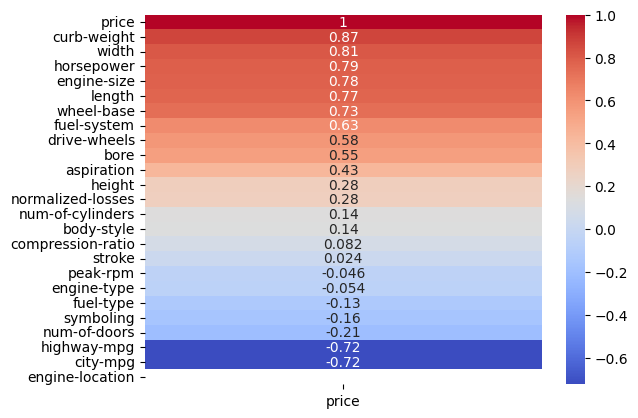

In [286]:
import seaborn as sns
corr=data.corr()
labeled_corr=corr[['price']].sort_values(by='price',ascending=False)
sns.heatmap(labeled_corr,annot=True,cmap='coolwarm')


In [287]:
X.drop('stroke',axis=1,inplace=True)

In [288]:
X.head()

,symboling,normalized-losses,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-type,num-of-cylinders,engine-size,fuel-system,bore,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
3,4,1.190059,1,0,0,3,1,0,0.392573,0.438895,...,2,1,-0.286970,4,-0.381297,0.009536,0.255059,0.801630,-0.458188,-0.382070
4,4,1.190059,1,0,0,3,0,0,0.308343,0.438895,...,2,0,0.768979,4,-0.381297,-0.546706,0.691494,0.801630,-1.456692,-1.657708
6,3,1.022486,1,0,0,3,1,0,1.656028,1.902509,...,2,0,0.768979,4,-0.381297,-0.407645,0.523635,0.801630,-1.290275,-1.179344
8,3,1.022486,1,1,0,3,1,0,1.656028,1.902509,...,2,0,0.573433,4,-0.606708,-0.463269,1.530792,0.801630,-1.623110,-1.976617
10,4,1.972067,1,0,1,3,2,0,0.687379,0.457077,...,2,1,-0.326079,4,0.783330,-0.324209,0.221487,1.457702,-0.624605,-0.541525


In [289]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True)



In [290]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print(r2_score(y_test,y_pred))



0.8199962481908328
